# 第135章: 物理動画の神経的生成 — ボール転がりシミュレーション (Capstone)

## 📋 この章で学ぶこと

この章を終えると、以下ができるようになります：

- [ ] NumPyで3種類の物理運動（等速直線・放物線・壁反射）をシミュレーションできる
- [ ] 物理シミュレーションから動画クリップを生成するDatasetを構築できる
- [ ] 時間的注意機構を持つPhysicsDiTモデルをスクラッチで実装できる
- [ ] DDPMで物理動画を訓練・生成できる
- [ ] 生成動画からボール軌跡を抽出し、物理法則の一貫性を定量評価できる

## 🎯 前提知識

- ✅ Notebook 130（Temporal Attention Fundamentals）
- ✅ Notebook 131（Video Diffusion Models）
- ✅ Notebook 132（Diffusion Transformer / DiT）
- ✅ Notebook 133（Camera vs Object Motion）
- ✅ Notebook 134（Temporal Consistency Techniques）
- ✅ Notebook 112（Adam Optimizer）

⏱️ **推定学習時間**: 240-300分
📊 **難易度**: ★★★★★（最上級 / Capstone）
🎓 **カテゴリ**: 時空間モデリング — 総合実践

## 目次

1. [物理シミュレータの構築](#section1)
2. [動画データセットの生成](#section2)
3. [PhysicsDiT — 時間的注意機構を持つ拡散Transformer](#section3)
4. [拡散訓練ループ](#section4)
5. [動画の生成とGIF出力](#section5)
6. [軌跡分析と物理的妥当性の検証](#section6)
7. [まとめ・よくあるエラー・自己評価クイズ](#summary)

In [1]:
# ============================================================
# 環境設定
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import math
import time
import warnings
import io

warnings.filterwarnings('ignore')

# 日本語フォント設定
def setup_japanese_font():
    japanese_fonts = [
        'Hiragino Sans', 'Hiragino Maru Gothic Pro',
        'Yu Gothic', 'MS Gothic',
        'Noto Sans CJK JP', 'IPAexGothic',
    ]
    available_fonts = set(f.name for f in fm.fontManager.ttflist)
    for font in japanese_fonts:
        if font in available_fonts:
            plt.rcParams['font.family'] = font
            plt.rcParams['axes.unicode_minus'] = False
            return font
    return None

font_used = setup_japanese_font()
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

# 再現性の確保
torch.manual_seed(42)
np.random.seed(42)

# デバイス設定
device = torch.device('cuda' if torch.cuda.is_available() else
                       'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'✅ ライブラリのインポート完了')
print(f'🖥️ デバイス: {device}')
print(f'📝 日本語フォント: {font_used}')

✅ ライブラリのインポート完了
🖥️ デバイス: cpu
📝 日本語フォント: Yu Gothic


<a id="section1"></a>
## 1. 物理シミュレータの構築

### 🎯 目標

生成モデルが「物理法則に従う動画」を生成できるかを評価するために、
まず **正確な物理シミュレーション** を行う2Dエンジンを構築します。

### 📊 3種類の運動

| 運動タイプ | 日本語 | 方程式 | 特徴 |
|-----------|--------|--------|------|
| `linear` | 等速直線運動 | $x = x_0 + v_x t$, $y = y_0 + v_y t$ | 一定速度で直進 |
| `parabolic` | 放物線運動 | $x = x_0 + v_x t$, $y = y_0 + v_y t + \frac{1}{2}g t^2$ | 重力による落下 |
| `bounce` | 壁反射運動 | 壁に当たると速度反転 | 反射の法則 |

### 🎬 出力仕様

- **フレーム数**: 16（動画の長さ）
- **解像度**: 32×32 RGB
- **ボール**: 半径3ピクセルの円
- **背景**: 黒（0, 0, 0）

In [2]:
# ============================================================
# PhysicsSimulator2D — NumPyベースの2D物理エンジン
# ============================================================

class PhysicsSimulator2D:
    """2D物理シミュレータ

    3種類の運動パターンでボール動画クリップを生成する。

    Attributes:
        H, W: フレームの高さ・幅（ピクセル）
        n_frames: 1クリップのフレーム数
        ball_radius: ボールの半径（ピクセル）
        gravity: 重力加速度（ピクセル/フレーム²）
        dt: 時間刻み
    """

    def __init__(self, H=32, W=32, n_frames=16, ball_radius=3,
                 gravity=0.4, dt=1.0):
        self.H = H
        self.W = W
        self.n_frames = n_frames
        self.ball_radius = ball_radius
        self.gravity = gravity
        self.dt = dt

    def _draw_ball(self, frame, cx, cy, color):
        """フレーム上にボール（円）を描画する

        Args:
            frame: (H, W, 3) numpy配列
            cx, cy: ボール中心座標
            color: (3,) RGB色 (0-1)
        """
        r = self.ball_radius
        # 描画範囲をクリップして安全に処理
        y_min = max(0, int(cy - r))
        y_max = min(self.H, int(cy + r) + 1)
        x_min = max(0, int(cx - r))
        x_max = min(self.W, int(cx + r) + 1)

        for y in range(y_min, y_max):
            for x in range(x_min, x_max):
                # 中心からの距離で円を描画
                dist = np.sqrt((x - cx)**2 + (y - cy)**2)
                if dist <= r:
                    # アンチエイリアス: 境界をなめらかに
                    alpha = max(0, 1.0 - max(0, dist - (r - 1.0)))
                    frame[y, x] = alpha * np.array(color) + (1 - alpha) * frame[y, x]

    def simulate_linear(self, rng=None):
        """等速直線運動をシミュレーション

        ボールが一定速度で直線的に移動する。
        ニュートンの第1法則（慣性の法則）に対応。

        Returns:
            frames: (n_frames, H, W, 3) numpy配列
            positions: (n_frames, 2) ボール中心座標
            label: 0 (線形運動のラベル)
        """
        if rng is None:
            rng = np.random.default_rng()

        # 初期位置: ボールが画面内に収まるように
        margin = self.ball_radius + 1
        x0 = rng.uniform(margin, self.W - margin)
        y0 = rng.uniform(margin, self.H - margin)

        # 速度: 画面を横断できる程度
        max_travel = (min(self.H, self.W) - 2 * margin) / self.n_frames
        vx = rng.uniform(-max_travel, max_travel)
        vy = rng.uniform(-max_travel, max_travel)
        # 最低速度を保証（静止を避ける）
        if abs(vx) + abs(vy) < 0.3:
            vx = 0.5 * (1 if rng.random() > 0.5 else -1)

        # ボール色: ランダムな明るい色
        color = rng.uniform(0.5, 1.0, size=3)

        frames = np.zeros((self.n_frames, self.H, self.W, 3), dtype=np.float32)
        positions = np.zeros((self.n_frames, 2), dtype=np.float32)

        for t in range(self.n_frames):
            cx = x0 + vx * t * self.dt
            cy = y0 + vy * t * self.dt
            # 画面外にはみ出さないようクリップ
            cx = np.clip(cx, margin, self.W - margin)
            cy = np.clip(cy, margin, self.H - margin)
            positions[t] = [cx, cy]
            self._draw_ball(frames[t], cx, cy, color)

        return frames, positions, 0

    def simulate_parabolic(self, rng=None):
        """放物線運動（重力あり）をシミュレーション

        水平方向は等速、垂直方向に重力加速度が作用。
        y(t) = y0 + vy*t + 0.5*g*t² の運動方程式に従う。

        Returns:
            frames: (n_frames, H, W, 3) numpy配列
            positions: (n_frames, 2) ボール中心座標
            label: 1 (放物線運動のラベル)
        """
        if rng is None:
            rng = np.random.default_rng()

        margin = self.ball_radius + 1
        # 上部から開始（落下を見せるため）
        x0 = rng.uniform(margin + 2, self.W - margin - 2)
        y0 = rng.uniform(margin, self.H * 0.35)

        # 水平速度: 小さめ / 垂直初速度: 上向きまたは小さい下向き
        vx = rng.uniform(-0.5, 0.5)
        vy = rng.uniform(-0.3, 0.2)  # 負=上向き

        color = rng.uniform(0.5, 1.0, size=3)

        frames = np.zeros((self.n_frames, self.H, self.W, 3), dtype=np.float32)
        positions = np.zeros((self.n_frames, 2), dtype=np.float32)

        for t in range(self.n_frames):
            cx = x0 + vx * t * self.dt
            # 放物線: y = y0 + vy*t + 0.5*g*t²
            cy = y0 + vy * t * self.dt + 0.5 * self.gravity * (t * self.dt)**2
            cx = np.clip(cx, margin, self.W - margin)
            cy = np.clip(cy, margin, self.H - margin)
            positions[t] = [cx, cy]
            self._draw_ball(frames[t], cx, cy, color)

        return frames, positions, 1

    def simulate_bounce(self, rng=None):
        """壁反射運動をシミュレーション

        ボールが壁に衝突すると速度の符号が反転する。
        完全弾性衝突を仮定（エネルギー損失なし）。

        Returns:
            frames: (n_frames, H, W, 3) numpy配列
            positions: (n_frames, 2) ボール中心座標
            label: 2 (壁反射運動のラベル)
        """
        if rng is None:
            rng = np.random.default_rng()

        margin = self.ball_radius + 1
        x = rng.uniform(margin + 2, self.W - margin - 2)
        y = rng.uniform(margin + 2, self.H - margin - 2)
        vx = rng.uniform(0.8, 1.5) * (1 if rng.random() > 0.5 else -1)
        vy = rng.uniform(0.8, 1.5) * (1 if rng.random() > 0.5 else -1)

        color = rng.uniform(0.5, 1.0, size=3)

        frames = np.zeros((self.n_frames, self.H, self.W, 3), dtype=np.float32)
        positions = np.zeros((self.n_frames, 2), dtype=np.float32)

        for t in range(self.n_frames):
            positions[t] = [x, y]
            self._draw_ball(frames[t], x, y, color)
            # 位置を更新
            x += vx * self.dt
            y += vy * self.dt
            # 壁反射: 境界に到達したら速度反転
            if x <= margin or x >= self.W - margin:
                vx = -vx
                x = np.clip(x, margin, self.W - margin)
            if y <= margin or y >= self.H - margin:
                vy = -vy
                y = np.clip(y, margin, self.H - margin)

        return frames, positions, 2

    def generate_clip(self, motion_type=None, rng=None):
        """指定された運動タイプのクリップを生成

        Args:
            motion_type: 'linear', 'parabolic', 'bounce', or None (ランダム)
            rng: numpy乱数ジェネレータ

        Returns:
            frames: (n_frames, H, W, 3) float32
            positions: (n_frames, 2) float32
            label: int (0=linear, 1=parabolic, 2=bounce)
        """
        if rng is None:
            rng = np.random.default_rng()

        if motion_type is None:
            motion_type = rng.choice(['linear', 'parabolic', 'bounce'])

        dispatch = {
            'linear': self.simulate_linear,
            'parabolic': self.simulate_parabolic,
            'bounce': self.simulate_bounce,
        }
        return dispatch[motion_type](rng=rng)

# テスト: シミュレータの動作確認
sim = PhysicsSimulator2D()
motion_types = ['linear', 'parabolic', 'bounce']
motion_names_jp = ['等速直線運動', '放物線運動', '壁反射運動']

print("PhysicsSimulator2D — 動作確認:")
print(f"  フレームサイズ: {sim.H}×{sim.W} RGB")
print(f"  フレーム数: {sim.n_frames}")
print(f"  ボール半径: {sim.ball_radius}px")
print(f"  重力: {sim.gravity} px/frame²")

for mt, name in zip(motion_types, motion_names_jp):
    frames, pos, label = sim.generate_clip(motion_type=mt, rng=np.random.default_rng(42))
    print(f"  [{name}] frames={frames.shape}, label={label}, "
          f"移動距離={np.linalg.norm(pos[-1]-pos[0]):.1f}px")

print("\n✅ シミュレータの構築完了")

PhysicsSimulator2D — 動作確認:
  フレームサイズ: 32×32 RGB
  フレーム数: 16
  ボール半径: 3px
  重力: 0.4 px/frame²
  [等速直線運動] frames=(16, 32, 32, 3), label=0, 移動距離=10.4px
  [放物線運動] frames=(16, 32, 32, 3), label=1, 移動距離=21.5px
  [壁反射運動] frames=(16, 32, 32, 3), label=2, 移動距離=15.0px

✅ シミュレータの構築完了


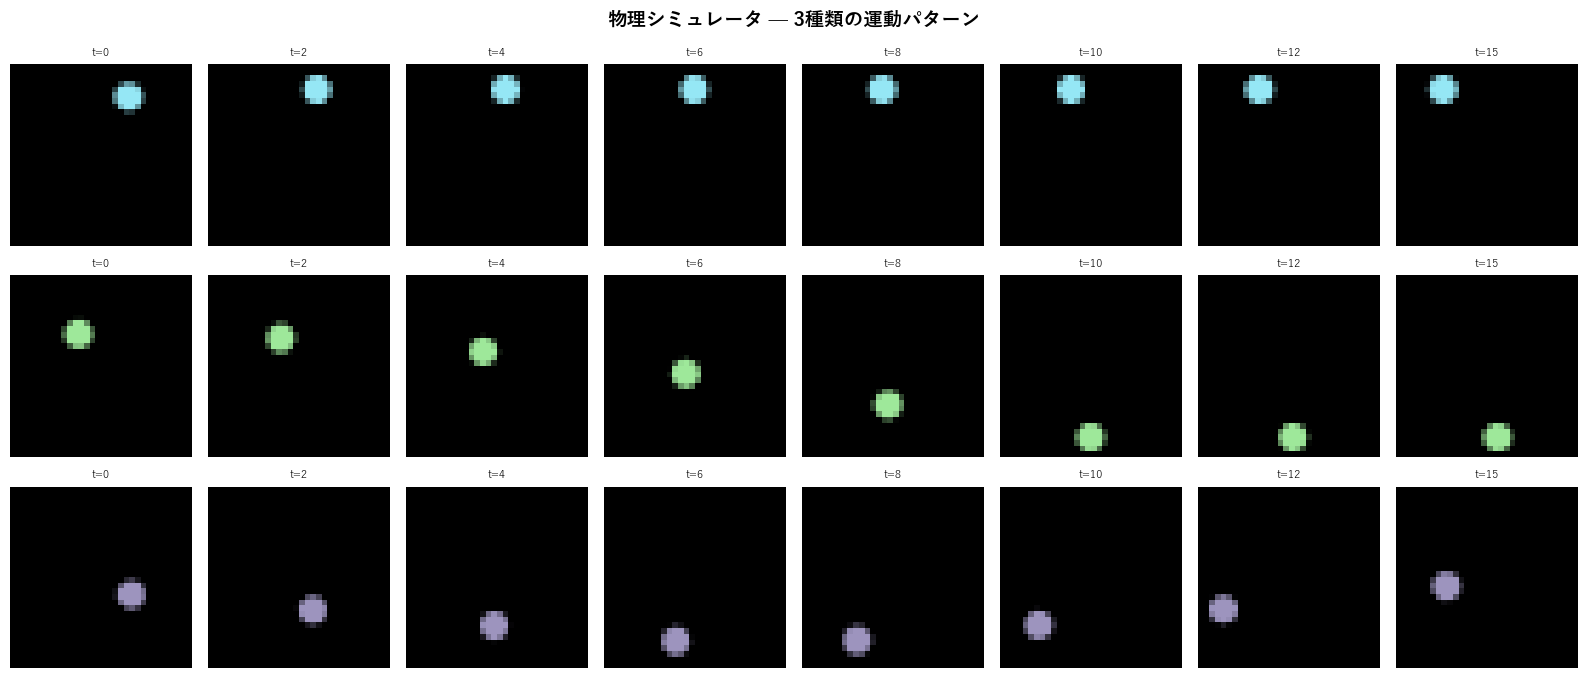

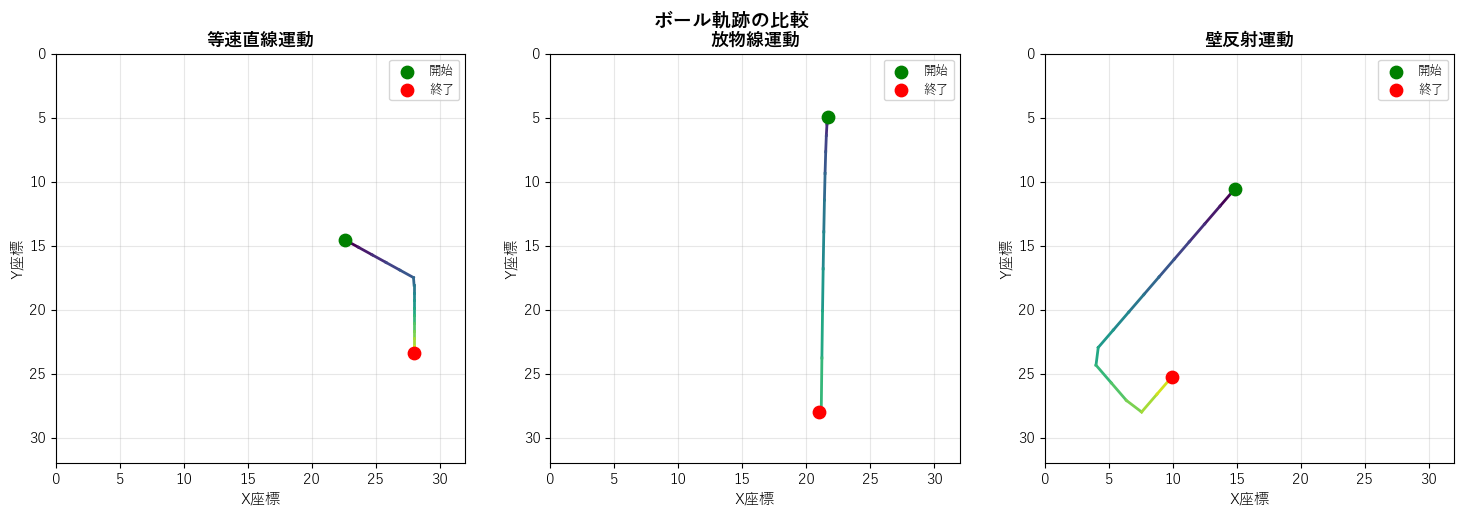

✅ 運動パターンの可視化完了


In [3]:
# ============================================================
# 3種類の運動パターンの可視化
# ============================================================

fig, axes = plt.subplots(3, 8, figsize=(16, 7))

sim = PhysicsSimulator2D()
rng = np.random.default_rng(123)

for row, (mt, name) in enumerate(zip(motion_types, motion_names_jp)):
    frames, positions, label = sim.generate_clip(motion_type=mt, rng=rng)
    # 16フレームから8フレームを等間隔で選択して表示
    indices = np.linspace(0, sim.n_frames - 1, 8, dtype=int)
    for col, idx in enumerate(indices):
        axes[row, col].imshow(frames[idx])
        axes[row, col].set_title(f't={idx}', fontsize=8)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(name, fontsize=11, rotation=0, labelpad=80, va='center')

fig.suptitle('物理シミュレータ — 3種類の運動パターン', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 軌跡プロット
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
rng = np.random.default_rng(42)

for ax, mt, name in zip(axes, motion_types, motion_names_jp):
    _, positions, _ = sim.generate_clip(motion_type=mt, rng=rng)
    colors = plt.cm.viridis(np.linspace(0, 1, len(positions)))
    for i in range(len(positions) - 1):
        ax.plot(positions[i:i+2, 0], positions[i:i+2, 1],
                color=colors[i], linewidth=2)
    ax.scatter(positions[0, 0], positions[0, 1], c='green', s=80,
               zorder=5, label='開始')
    ax.scatter(positions[-1, 0], positions[-1, 1], c='red', s=80,
               zorder=5, label='終了')
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('X座標')
    ax.set_ylabel('Y座標')
    ax.set_xlim(0, 32)
    ax.set_ylim(32, 0)  # 画像座標系（Y軸反転）
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

plt.suptitle('ボール軌跡の比較', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ 運動パターンの可視化完了")

<a id="section2"></a>
## 2. 動画データセットの生成

### 📊 設計方針

- **サンプル数**: 2000クリップ（CPU上でのデモに適したサイズ）
  - 各運動タイプ: 約667サンプル（均等分割）
- **テンソル形状**: `(T, C, H, W)` = `(16, 3, 32, 32)`
  - T: フレーム数（時間軸）
  - C: RGB 3チャンネル
  - H, W: 空間解像度
- **正規化**: `[0, 1]` → `[-1, 1]`（拡散モデルの標準的な入力範囲）

### 💡 ポイント

物理シミュレーションによるデータ生成は、実世界データと異なり：
1. **無限のデータ量**を生成できる
2. **完全な正解ラベル**（軌跡座標）が得られる
3. **物理法則の検証**が容易（解析解との比較が可能）

In [4]:
# ============================================================
# PhysicsVideoDataset — 物理動画データセット
# ============================================================

class PhysicsVideoDataset(Dataset):
    """物理シミュレーションによる動画データセット

    on-the-flyで動画を生成する（メモリ効率が良い）。
    ただし毎回同じデータを返すよう、インデックスベースのシードを使用。

    Args:
        n_samples: 総サンプル数
        sim: PhysicsSimulator2Dインスタンス
        base_seed: 乱数シード（再現性のため）
    """

    def __init__(self, n_samples=2000, sim=None, base_seed=0):
        self.n_samples = n_samples
        self.sim = sim or PhysicsSimulator2D()
        self.base_seed = base_seed
        self.motion_types = ['linear', 'parabolic', 'bounce']

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        """1サンプルを返す

        Returns:
            video: (T, C, H, W) torch.float32, [-1, 1]に正規化
            label: int, 運動タイプ (0/1/2)
        """
        # インデックスからシードを決定（再現性）
        rng = np.random.default_rng(self.base_seed + idx)
        # 運動タイプを均等に割り当て
        motion_type = self.motion_types[idx % 3]

        frames, positions, label = self.sim.generate_clip(
            motion_type=motion_type, rng=rng
        )

        # (T, H, W, C) → (T, C, H, W)
        video = torch.from_numpy(frames).permute(0, 3, 1, 2)
        # [0, 1] → [-1, 1] に正規化
        video = video * 2.0 - 1.0

        return video, label

# データセット生成テスト
dataset = PhysicsVideoDataset(n_samples=2000)
print(f"データセットサイズ: {len(dataset)}")
sample_video, sample_label = dataset[0]
print(f"動画テンソル形状: {sample_video.shape}")  # (16, 3, 32, 32)
print(f"値の範囲: [{sample_video.min():.2f}, {sample_video.max():.2f}]")
print(f"ラベル: {sample_label} ({motion_names_jp[sample_label]})")

# DataLoaderの設定
batch_size = 32
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True,
                        num_workers=0, drop_last=True)

# バッチの確認
batch_videos, batch_labels = next(iter(dataloader))
print(f"\nバッチ形状: {batch_videos.shape}")  # (32, 16, 3, 32, 32)
print(f"ラベル分布: {torch.bincount(torch.tensor(batch_labels), minlength=3).tolist()}")
print("✅ データセット構築完了")

データセットサイズ: 2000
動画テンソル形状: torch.Size([16, 3, 32, 32])
値の範囲: [-1.00, 0.91]
ラベル: 0 (等速直線運動)

バッチ形状: torch.Size([32, 16, 3, 32, 32])
ラベル分布: [10, 10, 12]
✅ データセット構築完了


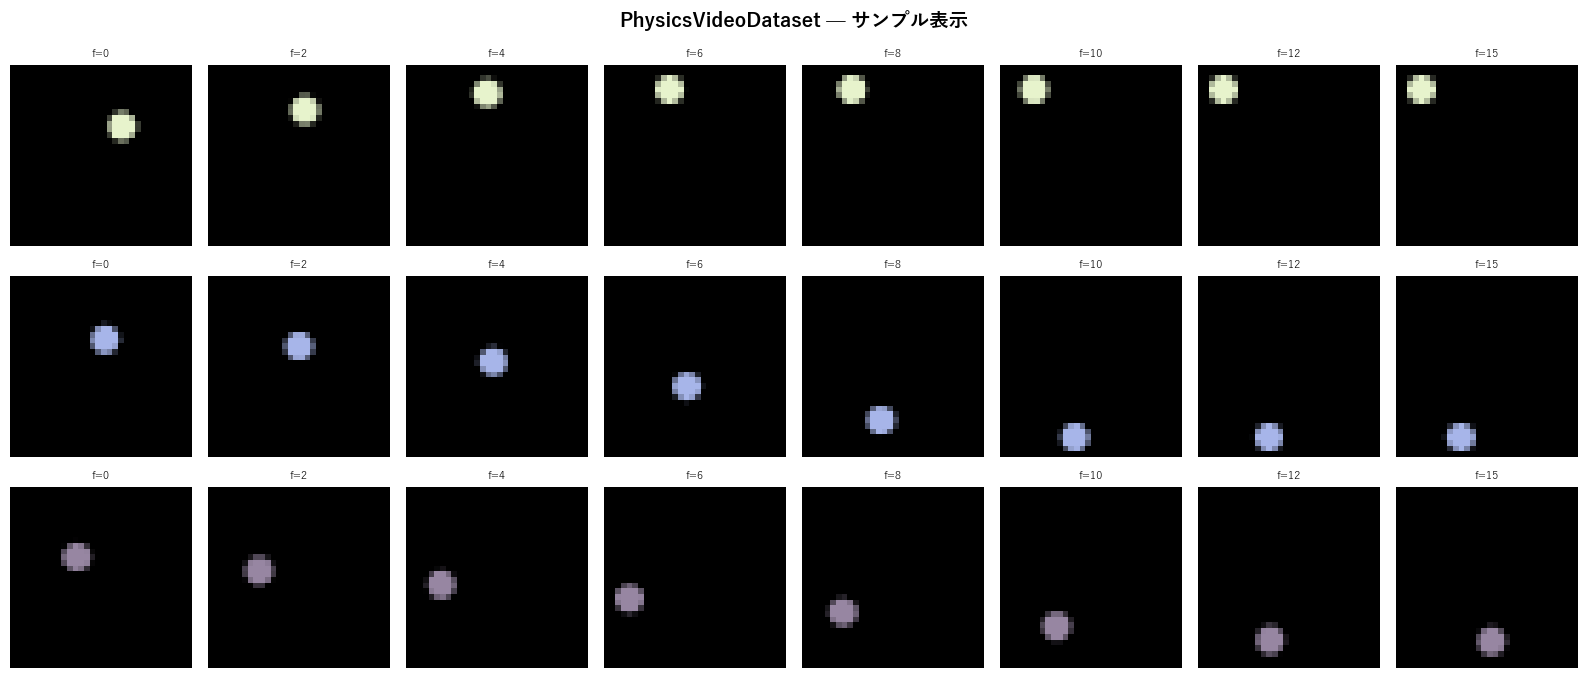

✅ データセットのサンプル可視化完了


In [5]:
# ============================================================
# データセットのサンプル可視化
# ============================================================

fig, axes = plt.subplots(3, 8, figsize=(16, 7))

for row in range(3):
    # 各運動タイプから1サンプル
    idx = row  # 0=linear, 1=parabolic, 2=bounce
    video, label = dataset[idx]
    # [-1,1] → [0,1] に戻す
    video_vis = (video + 1.0) / 2.0
    video_vis = video_vis.permute(0, 2, 3, 1).numpy()  # (T,H,W,C)

    indices = np.linspace(0, 15, 8, dtype=int)
    for col, t_idx in enumerate(indices):
        axes[row, col].imshow(video_vis[t_idx])
        axes[row, col].set_title(f'f={t_idx}', fontsize=8)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(motion_names_jp[label], fontsize=10,
                            rotation=0, labelpad=75, va='center')

fig.suptitle('PhysicsVideoDataset — サンプル表示', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ データセットのサンプル可視化完了")

<a id="section3"></a>
## 3. PhysicsDiT — 時間的注意機構を持つ拡散Transformer

### 📊 アーキテクチャ概要

```
入力: ノイズ付き動画 (B, T, C, H, W) + タイムステップ t
  ↓
各フレームを独立にパッチ化: (B*T, N_patches, dim)
  ↓
+ 空間位置埋め込み
  ↓
DiTBlock × 4（空間Self-Attention + adaLN-Zero）
  ↓
Reshape → (B, T, N_patches, dim)
  ↓
Temporal Self-Attention（フレーム間の時間的注意）
  ↓
Reshape → (B*T, N_patches, dim)
  ↓
Unpatchify → (B, T, C, H, W)
```

### 💡 設計のポイント

| パラメータ | 値 | 理由 |
|-----------|-----|------|
| パッチサイズ | 4×4 | 32/4 = 8 → 64パッチ/フレーム |
| 埋め込み次元 | 128 | CPU推論に十分小さい |
| レイヤ数 | 4 | デモ用の軽量設定 |
| ヘッド数 | 4 | dim/heads = 32（標準的） |
| 時間注意 | フレーム間 | 各パッチ位置で16フレームを結合 |

### 🔑 adaLN-Zero条件付け

Notebook 132で学んだadaLN-Zeroを使って拡散タイムステップを条件付けします：

$$\text{adaLN}(h, c) = \gamma(c) \cdot \text{LayerNorm}(h) + \beta(c)$$
$$\text{output} = h + \alpha(c) \cdot \text{Block}(\text{adaLN}(h, c))$$

ここで $\gamma, \beta, \alpha$ はすべて条件ベクトル $c$ から予測されます。

In [6]:
# ============================================================
# PhysicsDiT — 構成要素の実装
# ============================================================

def sinusoidal_embedding(timesteps, dim):
    """正弦波位置エンコーディング（拡散タイムステップ用）

    Args:
        timesteps: (B,) 整数テンソル
        dim: 埋め込み次元
    Returns:
        (B, dim) 正弦波埋め込み
    """
    half_dim = dim // 2
    emb = math.log(10000) / (half_dim - 1)
    emb = torch.exp(torch.arange(half_dim, device=timesteps.device) * -emb)
    emb = timesteps[:, None].float() * emb[None, :]
    emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
    return emb


class TimestepEmbedder(nn.Module):
    """拡散タイムステップの埋め込み

    Sinusoidal → MLP(dim → cond_dim)
    """
    def __init__(self, dim, cond_dim):
        super().__init__()
        self.dim = dim
        self.mlp = nn.Sequential(
            nn.Linear(dim, cond_dim),
            nn.SiLU(),
            nn.Linear(cond_dim, cond_dim),
        )

    def forward(self, t):
        emb = sinusoidal_embedding(t, self.dim)
        return self.mlp(emb)


class PatchEmbed(nn.Module):
    """画像をパッチに分割してトークン列に変換

    Conv2dを使って効率的にパッチ化する。
    入力: (B, C, H, W) → 出力: (B, N, dim)
    N = (H/patch_size) * (W/patch_size)
    """
    def __init__(self, in_channels=3, patch_size=4, dim=128):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_channels, dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x: (B, C, H, W) → (B, dim, H/p, W/p)
        x = self.proj(x)
        # (B, dim, H/p, W/p) → (B, N, dim)
        x = x.flatten(2).transpose(1, 2)
        return x


class Unpatchify(nn.Module):
    """トークン列を画像に復元

    Linear → Reshape → 画像
    (B, N, dim) → (B, C, H, W)
    """
    def __init__(self, dim=128, patch_size=4, out_channels=3, img_size=32):
        super().__init__()
        self.patch_size = patch_size
        self.grid_size = img_size // patch_size
        self.out_channels = out_channels
        # 各パッチを (patch_size² × out_channels) に展開
        self.linear = nn.Linear(dim, patch_size * patch_size * out_channels)

    def forward(self, x):
        # x: (B, N, dim) → (B, N, p*p*C)
        x = self.linear(x)
        B, N, _ = x.shape
        g = self.grid_size
        p = self.patch_size
        C = self.out_channels
        # (B, g, g, p, p, C) → (B, C, g*p, g*p)
        x = x.view(B, g, g, p, p, C)
        x = x.permute(0, 5, 1, 3, 2, 4).contiguous()
        x = x.view(B, C, g * p, g * p)
        return x


print("✅ PatchEmbed / Unpatchify / TimestepEmbedder 定義完了")

# 動作確認
test_img = torch.randn(2, 3, 32, 32)
pe = PatchEmbed(3, 4, 128)
tokens = pe(test_img)
print(f"PatchEmbed: {test_img.shape} → {tokens.shape}")  # (2, 64, 128)

up = Unpatchify(128, 4, 3, 32)
recon = up(tokens)
print(f"Unpatchify: {tokens.shape} → {recon.shape}")  # (2, 3, 32, 32)

te = TimestepEmbedder(128, 128)
t_emb = te(torch.tensor([10, 50]))
print(f"TimestepEmbedder: t=(2,) → {t_emb.shape}")  # (2, 128)

✅ PatchEmbed / Unpatchify / TimestepEmbedder 定義完了
PatchEmbed: torch.Size([2, 3, 32, 32]) → torch.Size([2, 64, 128])
Unpatchify: torch.Size([2, 64, 128]) → torch.Size([2, 3, 32, 32])
TimestepEmbedder: t=(2,) → torch.Size([2, 128])


In [7]:
# ============================================================
# DiTBlock — adaLN-Zero条件付きTransformerブロック
# ============================================================

class DiTBlock(nn.Module):
    """adaLN-Zero Transformerブロック

    標準的なTransformerブロック（Self-Attention + FFN）に
    adaLN-Zero条件付けを追加したもの。

    Args:
        dim: トークンの埋め込み次元
        n_heads: 注意ヘッド数
        mlp_ratio: FFNの隠れ層の倍率
    """
    def __init__(self, dim=128, n_heads=4, mlp_ratio=4.0):
        super().__init__()
        self.dim = dim
        self.n_heads = n_heads
        head_dim = dim // n_heads
        self.scale = head_dim ** -0.5

        # Self-Attention
        self.qkv = nn.Linear(dim, 3 * dim)
        self.attn_proj = nn.Linear(dim, dim)

        # FFN (Feed-Forward Network)
        hidden_dim = int(dim * mlp_ratio)
        self.ffn = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, dim),
        )

        # LayerNorm（adaLN-Zeroで変調される）
        self.norm1 = nn.LayerNorm(dim, elementwise_affine=False)
        self.norm2 = nn.LayerNorm(dim, elementwise_affine=False)

        # adaLN-Zero: 条件ベクトルから6つのパラメータを予測
        # γ1, β1, α1 (Attention用) + γ2, β2, α2 (FFN用)
        self.adaLN_modulation = nn.Sequential(
            nn.SiLU(),
            nn.Linear(dim, 6 * dim),
        )
        # α1, α2 をゼロ初期化（DiTの重要なトリック）
        nn.init.zeros_(self.adaLN_modulation[1].weight)
        nn.init.zeros_(self.adaLN_modulation[1].bias)

    def forward(self, x, c):
        """
        Args:
            x: (B, N, dim) トークン列
            c: (B, dim) 条件ベクトル（タイムステップ埋め込み）
        Returns:
            (B, N, dim) 変換後のトークン列
        """
        B, N, D = x.shape

        # adaLN-Zeroパラメータの取得
        modulation = self.adaLN_modulation(c)  # (B, 6*dim)
        gamma1, beta1, alpha1, gamma2, beta2, alpha2 = \
            modulation.chunk(6, dim=-1)  # 各 (B, dim)

        # --- Self-Attention + adaLN-Zero ---
        # 変調されたLayerNorm
        h = self.norm1(x)
        h = h * (1 + gamma1.unsqueeze(1)) + beta1.unsqueeze(1)

        # Multi-Head Self-Attention
        qkv = self.qkv(h).reshape(B, N, 3, self.n_heads, D // self.n_heads)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B, heads, N, head_dim)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) * self.scale  # (B, heads, N, N)
        attn = attn.softmax(dim=-1)
        h = (attn @ v).transpose(1, 2).reshape(B, N, D)
        h = self.attn_proj(h)

        # ゲーティング（α1）で残差接続
        x = x + alpha1.unsqueeze(1) * h

        # --- FFN + adaLN-Zero ---
        h = self.norm2(x)
        h = h * (1 + gamma2.unsqueeze(1)) + beta2.unsqueeze(1)
        h = self.ffn(h)
        x = x + alpha2.unsqueeze(1) * h

        return x

# 動作確認
block = DiTBlock(dim=128, n_heads=4)
test_tokens = torch.randn(2, 64, 128)
test_cond = torch.randn(2, 128)
out = block(test_tokens, test_cond)
print(f"DiTBlock: {test_tokens.shape} → {out.shape}")
n_params = sum(p.numel() for p in block.parameters())
print(f"DiTBlockパラメータ数: {n_params:,}")
print("✅ DiTBlock定義完了")

DiTBlock: torch.Size([2, 64, 128]) → torch.Size([2, 64, 128])
DiTBlockパラメータ数: 296,832
✅ DiTBlock定義完了


In [8]:
# ============================================================
# TemporalAttention — フレーム間の時間的注意機構
# ============================================================

class TemporalAttention(nn.Module):
    """フレーム間の時間的自己注意

    各空間パッチ位置について、全フレームにわたるSelf-Attentionを計算。
    これにより、モデルはフレーム間の時間的一貫性を学習する。

    Notebook 130で学んだTemporal Attentionの実装。

    入力: (B, T, N, dim) → 出力: (B, T, N, dim)
    注意: 各パッチ位置 n について (B, T, dim) に対してAttention
    """
    def __init__(self, dim=128, n_heads=4):
        super().__init__()
        self.n_heads = n_heads
        head_dim = dim // n_heads
        self.scale = head_dim ** -0.5

        self.norm = nn.LayerNorm(dim)
        self.qkv = nn.Linear(dim, 3 * dim)
        self.proj = nn.Linear(dim, dim)
        # 出力ゲートをゼロ初期化（学習初期は恒等写像）
        nn.init.zeros_(self.proj.weight)
        nn.init.zeros_(self.proj.bias)

    def forward(self, x):
        """
        Args:
            x: (B, T, N, dim) — B=バッチ, T=フレーム数, N=パッチ数
        Returns:
            (B, T, N, dim) 時間的注意を適用後
        """
        B, T, N, D = x.shape
        residual = x

        # (B, T, N, D) → (B*N, T, D) に変形
        # 各パッチ位置ごとに時間軸でAttention
        x = x.permute(0, 2, 1, 3).reshape(B * N, T, D)
        x = self.norm(x)

        qkv = self.qkv(x).reshape(B * N, T, 3, self.n_heads, D // self.n_heads)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B*N, heads, T, head_dim)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        x = (attn @ v).transpose(1, 2).reshape(B * N, T, D)
        x = self.proj(x)

        # (B*N, T, D) → (B, T, N, D)
        x = x.reshape(B, N, T, D).permute(0, 2, 1, 3)

        return residual + x

# 動作確認
temp_attn = TemporalAttention(dim=128, n_heads=4)
test_input = torch.randn(2, 16, 64, 128)  # (B, T, N, dim)
test_output = temp_attn(test_input)
print(f"TemporalAttention: {test_input.shape} → {test_output.shape}")
print("✅ TemporalAttention定義完了")

TemporalAttention: torch.Size([2, 16, 64, 128]) → torch.Size([2, 16, 64, 128])
✅ TemporalAttention定義完了


In [9]:
# ============================================================
# PhysicsDiT — 完全なモデル定義
# ============================================================

class PhysicsDiT(nn.Module):
    """物理動画生成用 Diffusion Transformer

    空間Self-Attention（各フレーム内）と
    時間Self-Attention（フレーム間）を組み合わせた軽量DiT。

    アーキテクチャ:
        PatchEmbed → [DiTBlock × n_layers] → TemporalAttn → Unpatchify

    Args:
        in_channels: 入力チャンネル数 (RGB=3)
        patch_size: パッチサイズ (4)
        dim: 埋め込み次元 (128)
        n_heads: 注意ヘッド数 (4)
        n_layers: DiTBlockの層数 (4)
        n_frames: フレーム数 (16)
        img_size: 画像サイズ (32)
    """
    def __init__(self, in_channels=3, patch_size=4, dim=128,
                 n_heads=4, n_layers=4, n_frames=16, img_size=32):
        super().__init__()
        self.n_frames = n_frames
        self.dim = dim
        n_patches = (img_size // patch_size) ** 2  # 64

        # パッチ埋め込み
        self.patch_embed = PatchEmbed(in_channels, patch_size, dim)

        # 学習可能な空間位置埋め込み
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches, dim))
        nn.init.normal_(self.pos_embed, std=0.02)

        # タイムステップ埋め込み（拡散ステップ）
        self.time_embed = TimestepEmbedder(dim, dim)

        # 空間DiTブロック（各フレーム独立に処理）
        self.spatial_blocks = nn.ModuleList([
            DiTBlock(dim, n_heads) for _ in range(n_layers)
        ])

        # 時間的注意機構（フレーム間の注意）
        self.temporal_attn = TemporalAttention(dim, n_heads)

        # 出力層: トークン → 画像
        self.final_norm = nn.LayerNorm(dim)
        self.unpatchify = Unpatchify(dim, patch_size, in_channels, img_size)

    def forward(self, x, t):
        """
        Args:
            x: (B, T, C, H, W) ノイズ付き動画テンソル
            t: (B,) 拡散タイムステップ
        Returns:
            noise_pred: (B, T, C, H, W) 予測ノイズ
        """
        B, T, C, H, W = x.shape

        # タイムステップ埋め込み
        t_emb = self.time_embed(t)  # (B, dim)

        # 全フレームをバッチに展開して空間処理
        # (B, T, C, H, W) → (B*T, C, H, W)
        x_flat = x.reshape(B * T, C, H, W)

        # パッチ埋め込み + 位置埋め込み
        tokens = self.patch_embed(x_flat)  # (B*T, N, dim)
        tokens = tokens + self.pos_embed

        # 条件ベクトルをフレーム数分に拡張
        # (B, dim) → (B*T, dim)
        t_emb_expanded = t_emb.unsqueeze(1).expand(-1, T, -1).reshape(B * T, -1)

        # 空間DiTブロック（各フレーム独立）
        for block in self.spatial_blocks:
            tokens = block(tokens, t_emb_expanded)

        # 時間的注意: (B*T, N, dim) → (B, T, N, dim)
        N = tokens.shape[1]
        tokens_4d = tokens.reshape(B, T, N, self.dim)
        tokens_4d = self.temporal_attn(tokens_4d)
        tokens = tokens_4d.reshape(B * T, N, self.dim)

        # 最終LayerNorm + Unpatchify
        tokens = self.final_norm(tokens)
        out = self.unpatchify(tokens)  # (B*T, C, H, W)

        # (B*T, C, H, W) → (B, T, C, H, W)
        out = out.reshape(B, T, C, H, W)
        return out

# モデル構築とパラメータ確認
model = PhysicsDiT(
    in_channels=3, patch_size=4, dim=128,
    n_heads=4, n_layers=4, n_frames=16, img_size=32
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 50)
print("PhysicsDiT モデル構成")
print("=" * 50)
print(f"  パッチサイズ: 4")
print(f"  埋め込み次元: 128")
print(f"  ヘッド数: 4")
print(f"  レイヤ数: 4")
print(f"  フレーム数: 16")
print(f"  画像サイズ: 32×32")
print(f"  総パラメータ数: {total_params:,}")
print(f"  学習可能パラメータ: {trainable_params:,}")
print(f"  メモリ概算: {total_params * 4 / 1024**2:.1f} MB (float32)")

# 推論テスト
with torch.no_grad():
    test_video = torch.randn(2, 16, 3, 32, 32).to(device)
    test_t = torch.randint(0, 200, (2,)).to(device)
    pred = model(test_video, test_t)
    print(f"\n推論テスト: {test_video.shape} → {pred.shape}")

print("\n✅ PhysicsDiTモデル構築完了")

PhysicsDiT モデル構成
  パッチサイズ: 4
  埋め込み次元: 128
  ヘッド数: 4
  レイヤ数: 4
  フレーム数: 16
  画像サイズ: 32×32
  総パラメータ数: 1,307,568
  学習可能パラメータ: 1,307,568
  メモリ概算: 5.0 MB (float32)

推論テスト: torch.Size([2, 16, 3, 32, 32]) → torch.Size([2, 16, 3, 32, 32])

✅ PhysicsDiTモデル構築完了


<a id="section4"></a>
## 4. 拡散訓練ループ

### 📊 拡散プロセスの設定

| パラメータ | 値 | 説明 |
|-----------|-----|------|
| 拡散ステップ数 (T) | 200 | 計算量を抑えるため少なめ |
| ノイズスケジュール | コサインスケジュール | 安定した学習に寄与 |
| 損失関数 | MSE（ε予測） | ε-predictionの標準的な定式化 |
| オプティマイザ | Adam (lr=3e-4) | Notebook 112で学んだAdam |
| エポック数 | 10 | CPUデモ用（実運用では100+） |

### 💡 コサインスケジュール

線形スケジュールの代わりにコサインスケジュールを使用します：

$$\bar{\alpha}_t = \frac{f(t)}{f(0)}, \quad f(t) = \cos\left(\frac{t/T + s}{1 + s} \cdot \frac{\pi}{2}\right)^2$$

コサインスケジュールは、拡散の後半でもノイズの変化が緩やかなため、
より安定した学習が可能です。

In [10]:
# ============================================================
# PhysicsVideoDiffusion — 拡散スケジュールと訓練
# ============================================================

class PhysicsVideoDiffusion:
    """物理動画用DDPM拡散プロセス

    Args:
        n_steps: 拡散ステップ数
        device: 計算デバイス
    """
    def __init__(self, n_steps=200, device='cpu'):
        self.n_steps = n_steps
        self.device = device

        # コサインスケジュール
        s = 0.008  # オフセット（ゼロ除算防止）
        steps = torch.arange(n_steps + 1, dtype=torch.float64) / n_steps
        f_t = torch.cos((steps + s) / (1 + s) * math.pi / 2) ** 2
        alphas_cumprod = f_t / f_t[0]

        # β_t = 1 - α_t/α_{t-1}
        betas = 1 - alphas_cumprod[1:] / alphas_cumprod[:-1]
        betas = torch.clamp(betas, max=0.999)

        alphas = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)

        # float32に変換してデバイスに移動
        self.betas = betas.float().to(device)
        self.alphas = alphas.float().to(device)
        self.alphas_cumprod = alphas_cumprod.float().to(device)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)

        # サンプリング用の係数
        self.sqrt_recip_alphas = torch.sqrt(1.0 / self.alphas)
        self.posterior_variance = (
            betas * (1.0 - torch.cat([torch.tensor([1.0]), alphas_cumprod[:-1]])) /
            (1.0 - alphas_cumprod)
        ).float().to(device)

    def q_sample(self, x0, t, noise=None):
        """前方拡散プロセス: x_0からx_tを生成

        q(x_t | x_0) = N(x_t; √ᾱ_t x_0, (1-ᾱ_t)I)

        Args:
            x0: (B, T, C, H, W) 元の動画
            t: (B,) タイムステップ
            noise: (B, T, C, H, W) ノイズ（Noneなら自動生成）
        Returns:
            x_t: ノイズ付き動画
            noise: 使用したノイズ
        """
        if noise is None:
            noise = torch.randn_like(x0)

        sqrt_alpha = self.sqrt_alphas_cumprod[t]
        sqrt_one_minus_alpha = self.sqrt_one_minus_alphas_cumprod[t]

        # ブロードキャスト用に次元を追加 (B,) → (B,1,1,1,1)
        while sqrt_alpha.dim() < x0.dim():
            sqrt_alpha = sqrt_alpha.unsqueeze(-1)
            sqrt_one_minus_alpha = sqrt_one_minus_alpha.unsqueeze(-1)

        x_t = sqrt_alpha * x0 + sqrt_one_minus_alpha * noise
        return x_t, noise

    @torch.no_grad()
    def p_sample(self, model, x_t, t_idx):
        """逆拡散ステップ: x_tからx_{t-1}を生成

        DDPM逆プロセスの1ステップ。

        Args:
            model: ノイズ予測モデル
            x_t: (B, T, C, H, W) 現在のノイズ状態
            t_idx: int 現在のタイムステップインデックス
        Returns:
            x_{t-1}: 1ステップデノイズされた動画
        """
        B = x_t.shape[0]
        t = torch.full((B,), t_idx, device=self.device, dtype=torch.long)

        # ノイズ予測
        noise_pred = model(x_t, t)

        # x_{t-1}の平均を計算
        beta_t = self.betas[t_idx]
        sqrt_one_minus_alpha_bar = self.sqrt_one_minus_alphas_cumprod[t_idx]
        sqrt_recip_alpha = self.sqrt_recip_alphas[t_idx]

        mean = sqrt_recip_alpha * (x_t - beta_t / sqrt_one_minus_alpha_bar * noise_pred)

        # t > 0 ならノイズを追加
        if t_idx > 0:
            noise = torch.randn_like(x_t)
            sigma = torch.sqrt(self.posterior_variance[t_idx])
            return mean + sigma * noise
        else:
            return mean

    @torch.no_grad()
    def sample(self, model, n_samples=4, n_frames=16, img_size=32, channels=3):
        """完全な逆拡散プロセスで動画を生成

        x_T ~ N(0, I) から開始し、T→0まで逐次デノイズ。

        Args:
            model: 学習済みPhysicsDiT
            n_samples: 生成する動画数
            n_frames: フレーム数
            img_size: 画像サイズ
            channels: チャンネル数
        Returns:
            samples: (n_samples, n_frames, C, H, W) 生成動画 [-1, 1]
        """
        model.eval()
        shape = (n_samples, n_frames, channels, img_size, img_size)

        # 純粋ノイズからスタート
        x = torch.randn(shape, device=self.device)

        # T-1 → 0 まで逆拡散
        for t_idx in reversed(range(self.n_steps)):
            x = self.p_sample(model, x, t_idx)
            if t_idx % 50 == 0:
                print(f"  サンプリング: t={t_idx}")

        # [-1, 1] → [0, 1] にクリップ
        x = torch.clamp(x, -1.0, 1.0)
        return x

# スケジュール確認
diffusion = PhysicsVideoDiffusion(n_steps=200, device=device)
print(f"拡散ステップ数: {diffusion.n_steps}")
print(f"β範囲: [{diffusion.betas[0]:.6f}, {diffusion.betas[-1]:.6f}]")
print(f"ᾱ範囲: [{diffusion.alphas_cumprod[0]:.4f}, {diffusion.alphas_cumprod[-1]:.6f}]")
print("✅ 拡散スケジュール設定完了")

拡散ステップ数: 200
β範囲: [0.000255, 0.999000]
ᾱ範囲: [0.9997, 0.000000]
✅ 拡散スケジュール設定完了


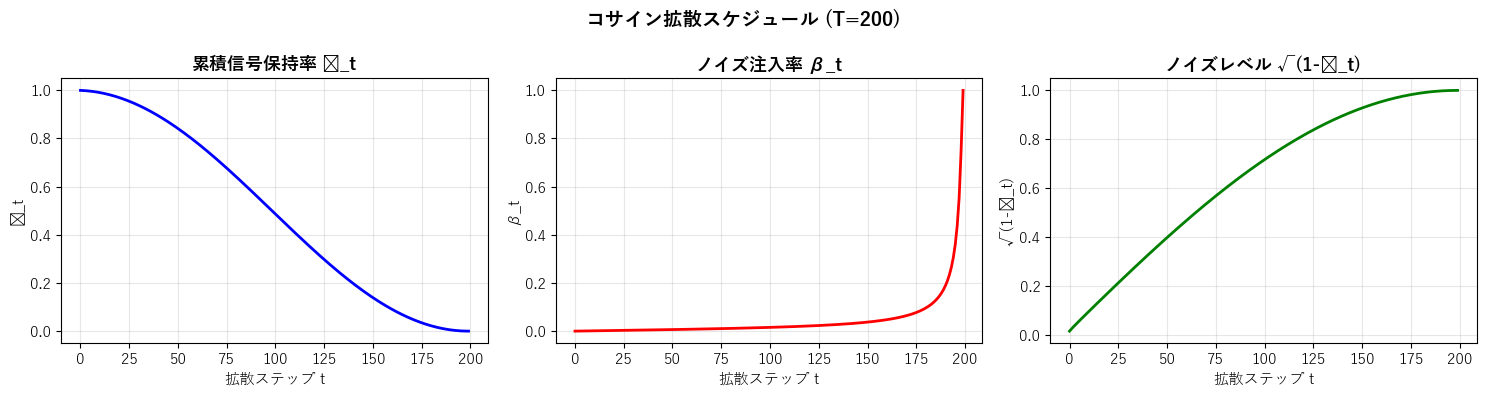

✅ スケジュール可視化完了


In [11]:
# ============================================================
# コサインスケジュールの可視化
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

steps = np.arange(diffusion.n_steps)

# (a) ᾱ_t
axes[0].plot(steps, diffusion.alphas_cumprod.cpu().numpy(), 'b-', linewidth=2)
axes[0].set_title('累積信号保持率 ᾱ_t', fontsize=13, fontweight='bold')
axes[0].set_xlabel('拡散ステップ t')
axes[0].set_ylabel('ᾱ_t')
axes[0].grid(True, alpha=0.3)

# (b) β_t
axes[1].plot(steps, diffusion.betas.cpu().numpy(), 'r-', linewidth=2)
axes[1].set_title('ノイズ注入率 β_t', fontsize=13, fontweight='bold')
axes[1].set_xlabel('拡散ステップ t')
axes[1].set_ylabel('β_t')
axes[1].grid(True, alpha=0.3)

# (c) √(1-ᾱ_t) — ノイズレベル
axes[2].plot(steps, diffusion.sqrt_one_minus_alphas_cumprod.cpu().numpy(),
             'g-', linewidth=2)
axes[2].set_title('ノイズレベル √(1-ᾱ_t)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('拡散ステップ t')
axes[2].set_ylabel('√(1-ᾱ_t)')
axes[2].grid(True, alpha=0.3)

plt.suptitle('コサイン拡散スケジュール (T=200)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ スケジュール可視化完了")

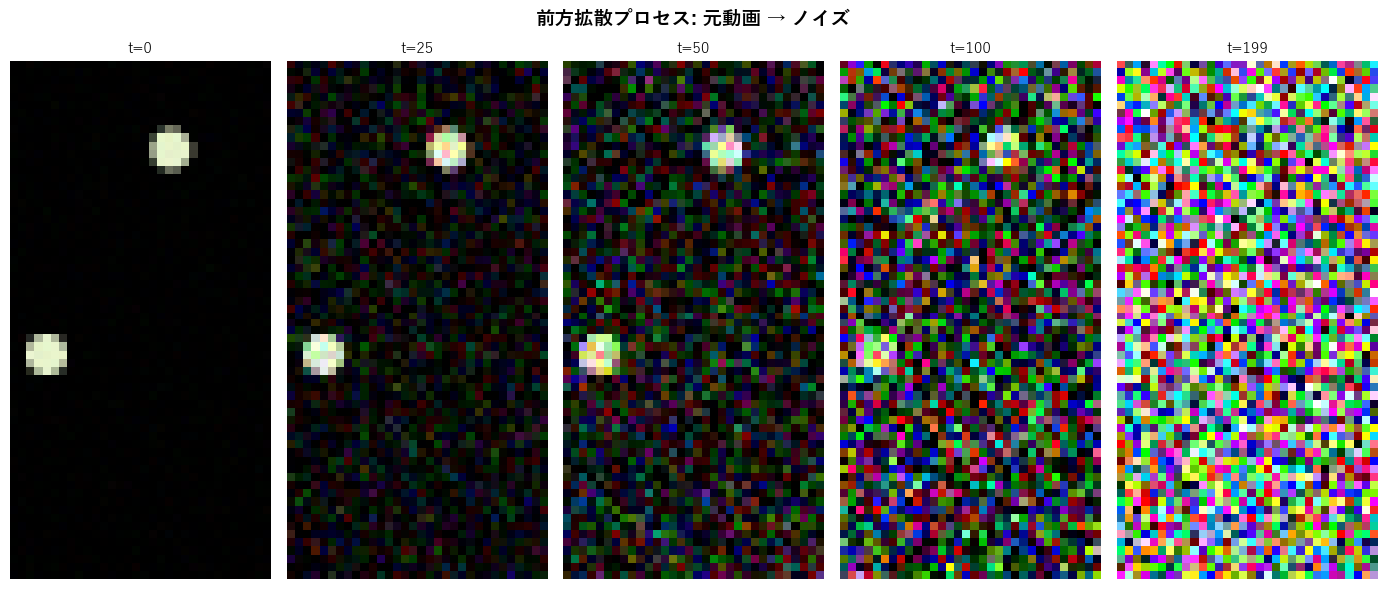

✅ 前方拡散の可視化完了


In [12]:
# ============================================================
# 前方拡散プロセスの可視化
# ============================================================

# 元動画からノイズ付き動画への変化を表示
sample_video, _ = dataset[0]
sample_video = sample_video.unsqueeze(0).to(device)  # (1, T, C, H, W)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
timesteps_to_show = [0, 25, 50, 100, 199]

for col, t_val in enumerate(timesteps_to_show):
    t = torch.tensor([t_val], device=device)
    x_t, _ = diffusion.q_sample(sample_video, t)

    # 最初のフレームを表示
    frame = x_t[0, 0].cpu()  # (C, H, W)
    frame = (frame + 1) / 2  # [-1,1] → [0,1]
    frame = frame.clamp(0, 1).permute(1, 2, 0).numpy()
    axes[0, col].imshow(frame)
    axes[0, col].set_title(f't={t_val}', fontsize=11)
    axes[0, col].axis('off')

    # 最後のフレームを表示
    frame_last = x_t[0, -1].cpu()
    frame_last = (frame_last + 1) / 2
    frame_last = frame_last.clamp(0, 1).permute(1, 2, 0).numpy()
    axes[1, col].imshow(frame_last)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('フレーム0', fontsize=11, rotation=0, labelpad=55, va='center')
axes[1, 0].set_ylabel('フレーム15', fontsize=11, rotation=0, labelpad=55, va='center')

fig.suptitle('前方拡散プロセス: 元動画 → ノイズ', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ 前方拡散の可視化完了")

In [13]:
# ============================================================
# 訓練ループ
# ============================================================
# 注意: CPU上では1エポックあたり数分かかります。
# 実験を早く終えたい場合は n_epochs を減らしてください。

n_epochs = 10
lr = 3e-4

# モデルを再初期化
model = PhysicsDiT(
    in_channels=3, patch_size=4, dim=128,
    n_heads=4, n_layers=4, n_frames=16, img_size=32
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
diffusion = PhysicsVideoDiffusion(n_steps=200, device=device)

# 小さめのデータセットで高速化
train_dataset = PhysicsVideoDataset(n_samples=600)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,
                          num_workers=0, drop_last=True)

loss_history = []
start_time = time.time()

print("=" * 60)
print("訓練開始")
print(f"  データ数: {len(train_dataset)}")
print(f"  バッチサイズ: 16")
print(f"  エポック数: {n_epochs}")
print(f"  学習率: {lr}")
print(f"  拡散ステップ: {diffusion.n_steps}")
print("=" * 60)

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0.0
    n_batches = 0

    for batch_idx, (videos, labels) in enumerate(train_loader):
        videos = videos.to(device)  # (B, T, C, H, W)
        B = videos.shape[0]

        # ランダムなタイムステップを選択
        t = torch.randint(0, diffusion.n_steps, (B,), device=device)

        # 前方拡散: x_0 → x_t
        noise = torch.randn_like(videos)
        x_t, _ = diffusion.q_sample(videos, t, noise=noise)

        # ノイズ予測
        noise_pred = model(x_t, t)

        # MSE損失
        loss = F.mse_loss(noise_pred, noise)

        optimizer.zero_grad()
        loss.backward()
        # 勾配クリッピング（安定性のため）
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += loss.item()
        n_batches += 1

    avg_loss = epoch_loss / n_batches
    loss_history.append(avg_loss)
    elapsed = time.time() - start_time

    print(f"  エポック {epoch+1:2d}/{n_epochs} | "
          f"損失: {avg_loss:.4f} | "
          f"経過時間: {elapsed:.0f}秒")

total_time = time.time() - start_time
print(f"\n✅ 訓練完了 — 総時間: {total_time:.0f}秒")
print(f"   最終損失: {loss_history[-1]:.4f}")

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.1.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


訓練開始
  データ数: 600
  バッチサイズ: 16
  エポック数: 10
  学習率: 0.0003
  拡散ステップ: 200
  エポック  1/10 | 損失: 0.9575 | 経過時間: 81秒
  エポック  2/10 | 損失: 0.2966 | 経過時間: 147秒
  エポック  3/10 | 損失: 0.1308 | 経過時間: 253秒
  エポック  4/10 | 損失: 0.0962 | 経過時間: 372秒
  エポック  5/10 | 損失: 0.0754 | 経過時間: 433秒
  エポック  6/10 | 損失: 0.0728 | 経過時間: 509秒
  エポック  7/10 | 損失: 0.0667 | 経過時間: 576秒
  エポック  8/10 | 損失: 0.0646 | 経過時間: 637秒
  エポック  9/10 | 損失: 0.0571 | 経過時間: 692秒
  エポック 10/10 | 損失: 0.0500 | 経過時間: 750秒

✅ 訓練完了 — 総時間: 750秒
   最終損失: 0.0500


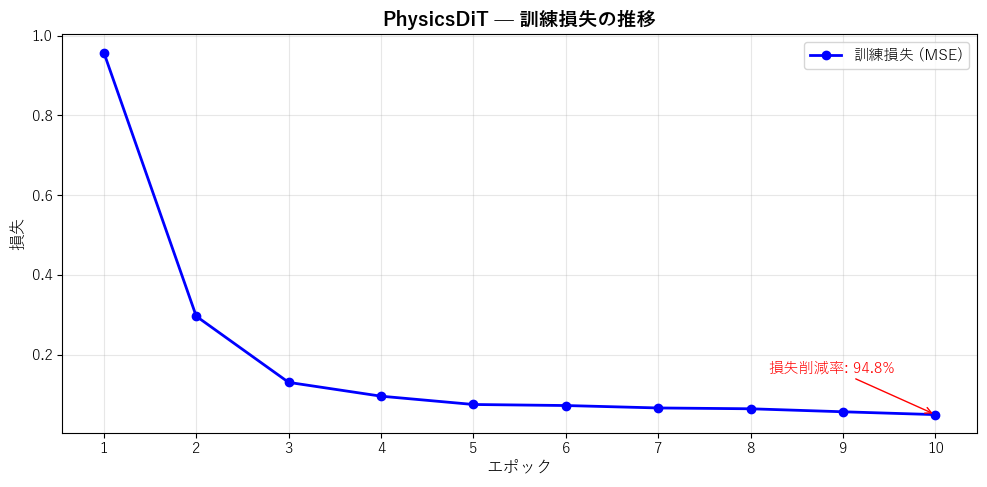

✅ 損失曲線の可視化完了


In [14]:
# ============================================================
# 損失曲線の可視化
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.plot(range(1, len(loss_history) + 1), loss_history, 'b-o',
        linewidth=2, markersize=6, label='訓練損失 (MSE)')
ax.set_xlabel('エポック', fontsize=12)
ax.set_ylabel('損失', fontsize=12)
ax.set_title('PhysicsDiT — 訓練損失の推移', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xticks(range(1, len(loss_history) + 1))

# 損失の減少率を計算
if len(loss_history) >= 2:
    reduction = (loss_history[0] - loss_history[-1]) / loss_history[0] * 100
    ax.annotate(f'損失削減率: {reduction:.1f}%',
                xy=(len(loss_history), loss_history[-1]),
                xytext=(-120, 30), textcoords='offset points',
                fontsize=11, color='red',
                arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.show()
print("✅ 損失曲線の可視化完了")

<a id="section5"></a>
## 5. 動画の生成とGIF出力

### 🎬 DDPMサンプリング

訓練したモデルを使って、純粋なガウスノイズから動画を生成します。

**逆拡散プロセス**:
$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{\beta_t}{\sqrt{1 - \bar{\alpha}_t}} \epsilon_\theta(x_t, t) \right) + \sigma_t z$$

ここで $z \sim \mathcal{N}(0, I)$ (t > 0の場合のみ)。

### 💡 注意点

- CPU上でのサンプリングは200ステップ × 4サンプル分の推論が必要
- 10エポックの訓練では完全な物理的一貫性は期待できませんが、
  ボールの存在と大まかな動きパターンは学習されます

In [15]:
# ============================================================
# 動画の生成
# ============================================================

print("サンプリング開始...")
print("（CPU上では数分かかる場合があります）")

n_gen = 4  # 生成サンプル数
generated = diffusion.sample(model, n_samples=n_gen, n_frames=16,
                             img_size=32, channels=3)

# (n_gen, T, C, H, W), [-1, 1]
print(f"\n生成完了: {generated.shape}")
print(f"値の範囲: [{generated.min():.3f}, {generated.max():.3f}]")

# [−1, 1] → [0, 1]
generated_vis = (generated + 1.0) / 2.0
generated_vis = generated_vis.clamp(0, 1)

print("✅ 動画の生成完了")

サンプリング開始...
（CPU上では数分かかる場合があります）
  サンプリング: t=150
  サンプリング: t=100
  サンプリング: t=50
  サンプリング: t=0

生成完了: torch.Size([4, 16, 3, 32, 32])
値の範囲: [-1.000, 1.000]
✅ 動画の生成完了


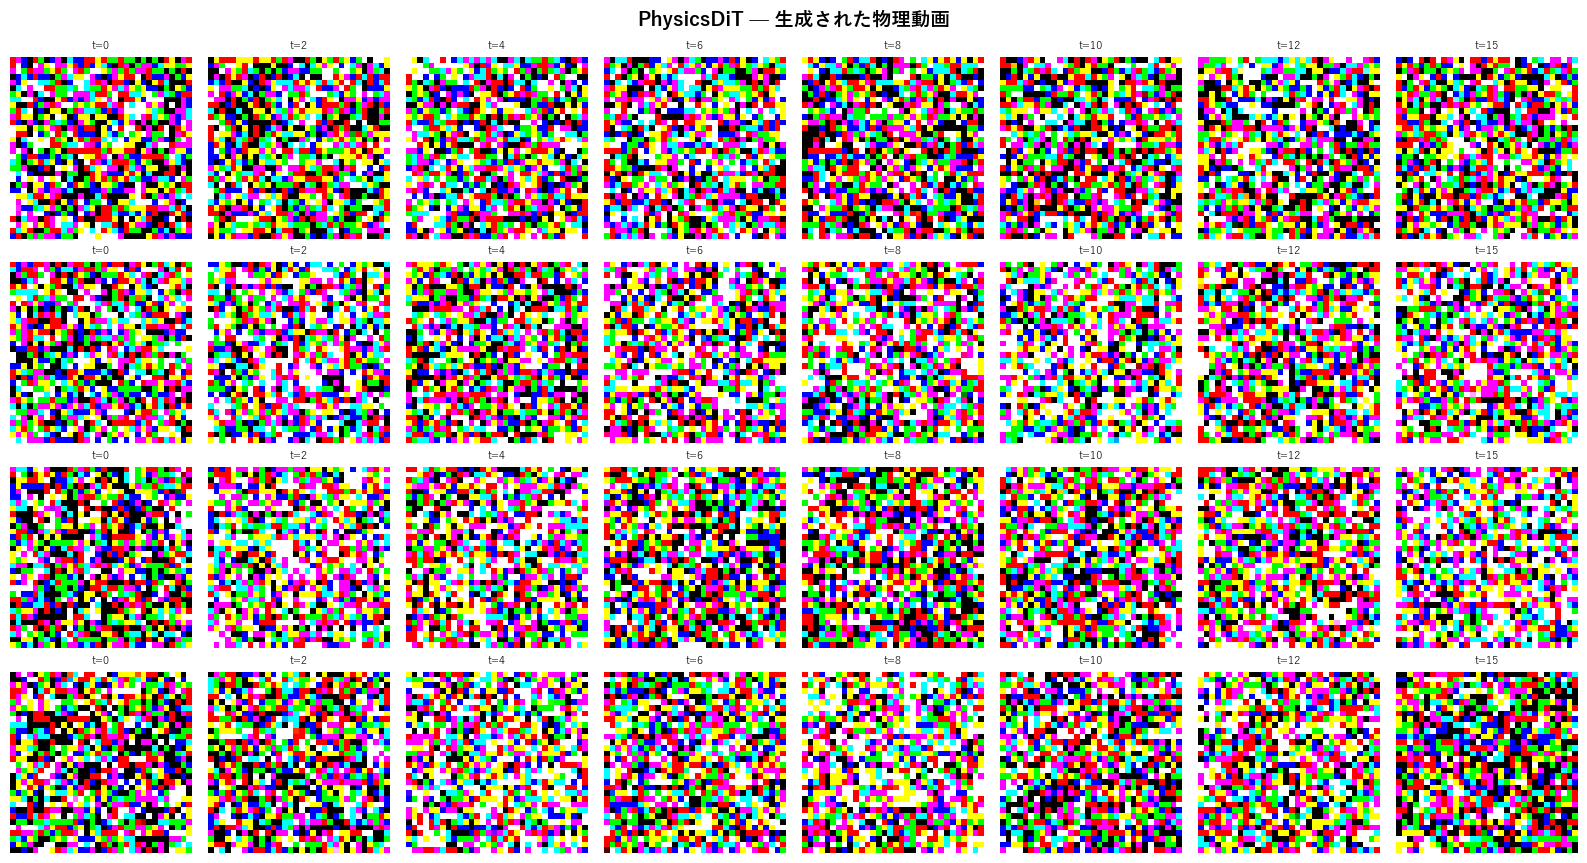

✅ 生成動画の可視化完了


In [16]:
# ============================================================
# 生成動画の可視化
# ============================================================

n_show = min(4, n_gen)
fig, axes = plt.subplots(n_show, 8, figsize=(16, 2.2 * n_show))
if n_show == 1:
    axes = axes[np.newaxis, :]

frame_indices = np.linspace(0, 15, 8, dtype=int)

for row in range(n_show):
    video = generated_vis[row]  # (T, C, H, W)
    for col, t_idx in enumerate(frame_indices):
        frame = video[t_idx].cpu().permute(1, 2, 0).numpy()
        axes[row, col].imshow(frame)
        axes[row, col].set_title(f't={t_idx}', fontsize=8)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(f'Sample {row}', fontsize=10,
                            rotation=0, labelpad=55, va='center')

fig.suptitle('PhysicsDiT — 生成された物理動画', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ 生成動画の可視化完了")

In [17]:
# ============================================================
# GIF出力（オプション — imageioが必要）
# ============================================================

try:
    import imageio

    # 最初の生成動画をGIFとして保存
    video_for_gif = generated_vis[0].cpu().permute(0, 2, 3, 1).numpy()  # (T, H, W, C)
    # 解像度を拡大（見やすくするため）
    scale = 8
    H, W = video_for_gif.shape[1], video_for_gif.shape[2]
    frames_scaled = []
    for frame in video_for_gif:
        frame_uint8 = (frame * 255).astype(np.uint8)
        # 最近傍補間でスケールアップ
        frame_large = np.repeat(np.repeat(frame_uint8, scale, axis=0), scale, axis=1)
        frames_scaled.append(frame_large)

    gif_path = 'physics_generated.gif'
    imageio.mimsave(gif_path, frames_scaled, fps=8, loop=0)
    print(f"✅ GIF保存完了: {gif_path}")
    print(f"   フレーム数: {len(frames_scaled)}, サイズ: {frames_scaled[0].shape}")

except ImportError:
    print("⚠️ imageioがインストールされていません。")
    print("   pip install imageio でインストールしてからGIF出力を試してください。")
    print("   動画の可視化はmatplotlibの表示で代替できます。")

✅ GIF保存完了: physics_generated.gif
   フレーム数: 16, サイズ: (256, 256, 3)


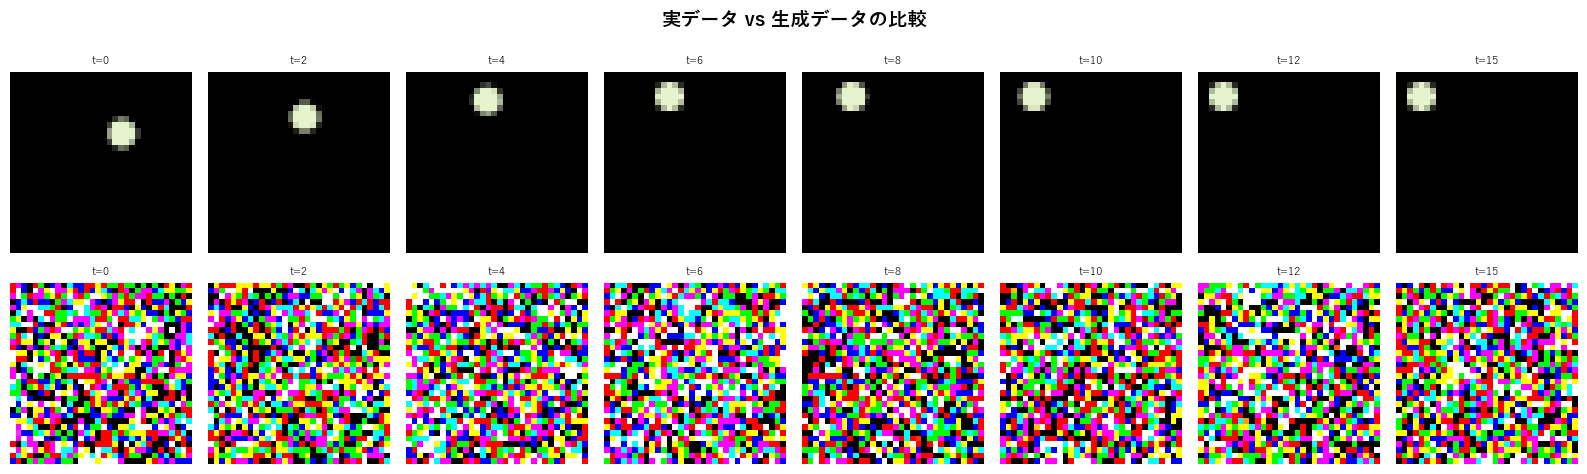

✅ 実データ vs 生成データの比較完了


In [18]:
# ============================================================
# 実データ vs 生成データの比較
# ============================================================

fig, axes = plt.subplots(2, 8, figsize=(16, 5))

# 実データ（上段）
real_video, real_label = dataset[0]
real_vis = (real_video + 1) / 2
real_vis = real_vis.clamp(0, 1).permute(0, 2, 3, 1).numpy()

# 生成データ（下段）
gen_vis = generated_vis[0].cpu().permute(0, 2, 3, 1).numpy()

frame_indices = np.linspace(0, 15, 8, dtype=int)

for col, t_idx in enumerate(frame_indices):
    axes[0, col].imshow(real_vis[t_idx])
    axes[0, col].set_title(f't={t_idx}', fontsize=8)
    axes[0, col].axis('off')

    axes[1, col].imshow(gen_vis[t_idx])
    axes[1, col].set_title(f't={t_idx}', fontsize=8)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('実データ', fontsize=11, rotation=0, labelpad=55, va='center')
axes[1, 0].set_ylabel('生成データ', fontsize=11, rotation=0, labelpad=55, va='center')

fig.suptitle('実データ vs 生成データの比較', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ 実データ vs 生成データの比較完了")

<a id="section6"></a>
## 6. 軌跡分析と物理的妥当性の検証

### 🔬 TrajectoryAnalyzer

生成された動画からボールの位置を抽出し、
物理法則に一貫した動きをしているかを定量的に評価します。

### 📊 分析手法

1. **ボール位置の抽出**: 各フレームの最も明るいピクセル領域の重心を計算
2. **軌跡のフィッティング**:
   - 線形フィット: $r(t) = at + b$ → R²で直線性を評価
   - 放物線フィット: $y(t) = at^2 + bt + c$ → R²と重力定数を推定
3. **運動タイプの分類**: R²と重力推定値から自動判定

### 💡 物理的妥当性の指標

- **R²値**: 1に近いほど理論曲線への適合が良い
- **推定重力定数**: シミュレータの設定値（0.4）に近いか
- **速度の一貫性**: フレーム間の速度変化が物理的に合理的か

In [19]:
# ============================================================
# TrajectoryAnalyzer — 軌跡分析と物理的妥当性の検証
# ============================================================

class TrajectoryAnalyzer:
    """生成動画からボール軌跡を抽出し物理的妥当性を評価

    主な機能:
    1. フレームからボール位置を抽出（輝度重心法）
    2. 線形/放物線フィッティングとR²計算
    3. 重力定数の推定
    4. 運動タイプの自動分類
    """

    def __init__(self, sim_gravity=0.4):
        """
        Args:
            sim_gravity: シミュレータで設定した重力加速度
        """
        self.sim_gravity = sim_gravity

    def extract_positions(self, video):
        """動画フレームからボール中心位置を抽出

        各フレームの輝度（RGB平均）を計算し、
        閾値以上のピクセルの重心をボール位置とする。

        Args:
            video: (T, H, W, 3) numpy配列, [0, 1]
        Returns:
            positions: (T, 2) numpy配列 [x, y]
            valid: bool 有効な軌跡が得られたか
        """
        T, H, W, C = video.shape
        positions = np.zeros((T, 2), dtype=np.float32)

        for t in range(T):
            frame = video[t]
            # 輝度マップ（RGB平均）
            brightness = frame.mean(axis=-1)

            # 閾値: 平均 + 2*標準偏差
            threshold = brightness.mean() + 2.0 * brightness.std()
            threshold = max(threshold, 0.15)  # 最低閾値

            # 閾値以上のピクセルの重心
            mask = brightness > threshold
            if mask.sum() > 0:
                ys, xs = np.where(mask)
                weights = brightness[mask]
                positions[t, 0] = np.average(xs, weights=weights)
                positions[t, 1] = np.average(ys, weights=weights)
            else:
                # ボールが見つからない場合は前フレームの位置を使用
                if t > 0:
                    positions[t] = positions[t-1]
                else:
                    positions[t] = [W/2, H/2]

        # 有効性チェック: ボールがほとんど動いていない場合は無効
        total_movement = np.sum(np.linalg.norm(np.diff(positions, axis=0), axis=1))
        valid = total_movement > 3.0

        return positions, valid

    def fit_linear(self, positions):
        """線形フィット（等速直線運動の検証）

        x(t) = a_x * t + b_x
        y(t) = a_y * t + b_y

        Args:
            positions: (T, 2) numpy配列
        Returns:
            r2_x, r2_y: 各軸のR²値
            r2_combined: 合計R²
            params: (a_x, b_x, a_y, b_y)
        """
        T = len(positions)
        t = np.arange(T, dtype=np.float64)

        # X軸の線形フィット
        coeffs_x = np.polyfit(t, positions[:, 0], 1)
        pred_x = np.polyval(coeffs_x, t)
        ss_res_x = np.sum((positions[:, 0] - pred_x)**2)
        ss_tot_x = np.sum((positions[:, 0] - positions[:, 0].mean())**2)
        r2_x = 1 - ss_res_x / (ss_tot_x + 1e-8)

        # Y軸の線形フィット
        coeffs_y = np.polyfit(t, positions[:, 1], 1)
        pred_y = np.polyval(coeffs_y, t)
        ss_res_y = np.sum((positions[:, 1] - pred_y)**2)
        ss_tot_y = np.sum((positions[:, 1] - positions[:, 1].mean())**2)
        r2_y = 1 - ss_res_y / (ss_tot_y + 1e-8)

        r2_combined = (r2_x + r2_y) / 2
        return r2_x, r2_y, r2_combined, (coeffs_x, coeffs_y)

    def fit_parabolic(self, positions):
        """放物線フィット（重力運動の検証）

        x(t) = a_x * t + b_x （水平: 線形）
        y(t) = a_y * t² + b_y * t + c_y （垂直: 放物線）

        Args:
            positions: (T, 2) numpy配列
        Returns:
            r2_y: Y軸の放物線R²
            estimated_gravity: 推定重力定数 (2 * a_y)
            params: フィットパラメータ
        """
        T = len(positions)
        t = np.arange(T, dtype=np.float64)

        # Y軸の放物線フィット（2次多項式）
        coeffs_y = np.polyfit(t, positions[:, 1], 2)
        pred_y = np.polyval(coeffs_y, t)
        ss_res = np.sum((positions[:, 1] - pred_y)**2)
        ss_tot = np.sum((positions[:, 1] - positions[:, 1].mean())**2)
        r2_y = 1 - ss_res / (ss_tot + 1e-8)

        # 重力推定: y = 0.5*g*t² + ... → a_y ≈ 0.5*g → g ≈ 2*a_y
        estimated_gravity = 2.0 * coeffs_y[0]

        return r2_y, estimated_gravity, coeffs_y

    def classify_motion(self, positions):
        """軌跡から運動タイプを自動分類

        判定基準:
        1. 線形R² > 0.9 かつ 放物線改善が小さい → 等速直線
        2. 放物線R² > 0.85 かつ 重力推定値が正 → 放物線
        3. 速度変化にサイン変化がある → 壁反射
        4. それ以外 → 未分類

        Returns:
            motion_type: str ('linear', 'parabolic', 'bounce', 'unknown')
            confidence: float 確信度
            details: dict 詳細情報
        """
        r2_x, r2_y, r2_linear, _ = self.fit_linear(positions)
        r2_parabolic, est_gravity, _ = self.fit_parabolic(positions)

        # 速度変化の分析（壁反射の検出）
        velocities = np.diff(positions, axis=0)
        # 速度の符号が変わる回数
        sign_changes_x = np.sum(np.abs(np.diff(np.sign(velocities[:, 0]))) > 0)
        sign_changes_y = np.sum(np.abs(np.diff(np.sign(velocities[:, 1]))) > 0)
        total_sign_changes = sign_changes_x + sign_changes_y

        details = {
            'r2_linear': r2_linear,
            'r2_parabolic': r2_parabolic,
            'est_gravity': est_gravity,
            'sign_changes': total_sign_changes,
        }

        # 分類ロジック
        if total_sign_changes >= 2:
            return 'bounce', min(total_sign_changes / 4.0, 1.0), details
        elif r2_parabolic > 0.85 and est_gravity > 0.1:
            improvement = r2_parabolic - r2_linear
            if improvement > 0.05:
                return 'parabolic', r2_parabolic, details

        if r2_linear > 0.85:
            return 'linear', r2_linear, details

        return 'unknown', 0.0, details

    def analyze_video(self, video):
        """動画の完全な軌跡分析

        Args:
            video: (T, H, W, 3) numpy配列, [0, 1]
        Returns:
            result: dict 分析結果
        """
        positions, valid = self.extract_positions(video)

        if not valid:
            return {
                'valid': False,
                'positions': positions,
                'motion_type': 'unknown',
                'message': '有効な軌跡を検出できませんでした'
            }

        motion_type, confidence, details = self.classify_motion(positions)
        r2_x, r2_y, r2_linear, linear_params = self.fit_linear(positions)
        r2_parabolic, est_gravity, parabolic_params = self.fit_parabolic(positions)

        return {
            'valid': True,
            'positions': positions,
            'motion_type': motion_type,
            'confidence': confidence,
            'r2_linear': r2_linear,
            'r2_parabolic': r2_parabolic,
            'est_gravity': est_gravity,
            'details': details,
            'linear_params': linear_params,
            'parabolic_params': parabolic_params,
        }

print("✅ TrajectoryAnalyzer定義完了")

✅ TrajectoryAnalyzer定義完了


実データの軌跡分析（グラウンドトゥルースとの比較）
  [等速直線運動] 平均位置誤差: 0.04px, R²(線形): 0.808, R²(放物線): 1.000, 判定: unknown
  [放物線運動] 平均位置誤差: 0.04px, R²(線形): 0.973, R²(放物線): 0.948, 判定: linear
  [壁反射運動] 平均位置誤差: 0.05px, R²(線形): 1.000, R²(放物線): 1.000, 判定: linear


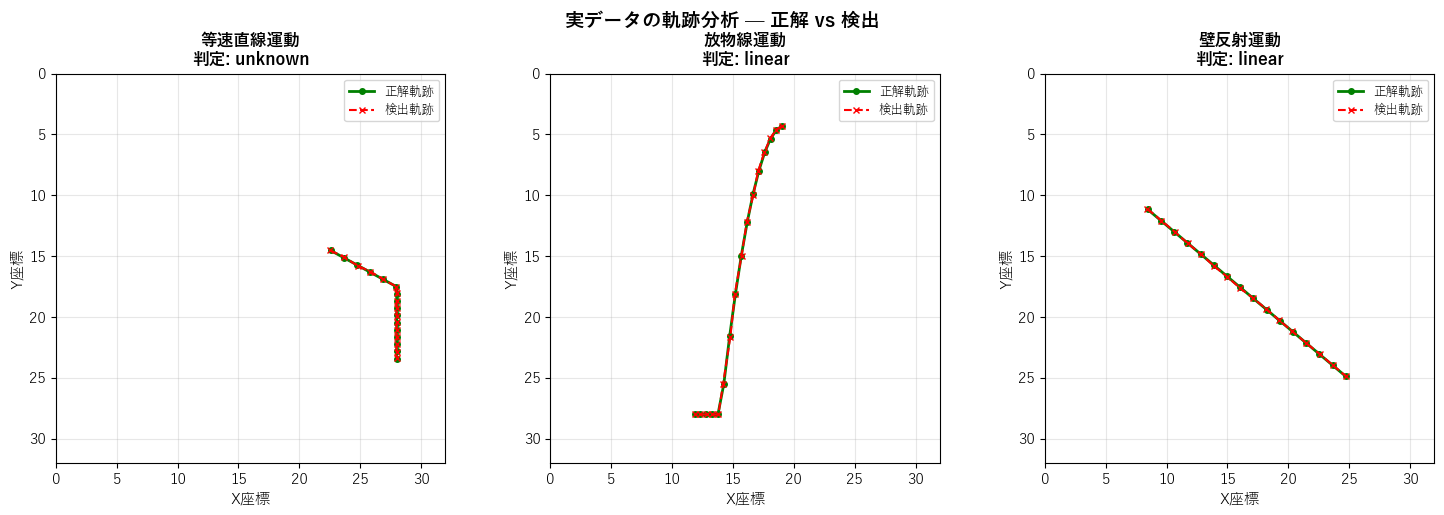


✅ 実データの軌跡分析完了


In [20]:
# ============================================================
# 実データの軌跡分析（検証）
# ============================================================

analyzer = TrajectoryAnalyzer(sim_gravity=0.4)
sim = PhysicsSimulator2D()

print("=" * 60)
print("実データの軌跡分析（グラウンドトゥルースとの比較）")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (mt, name) in enumerate(zip(motion_types, motion_names_jp)):
    rng = np.random.default_rng(42 + idx)
    frames, gt_positions, label = sim.generate_clip(motion_type=mt, rng=rng)

    # TrajectoryAnalyzerで位置を抽出
    result = analyzer.analyze_video(frames)
    detected_pos = result['positions']

    ax = axes[idx]
    # グラウンドトゥルース
    ax.plot(gt_positions[:, 0], gt_positions[:, 1], 'g-o',
            markersize=4, label='正解軌跡', linewidth=2)
    # 検出された軌跡
    ax.plot(detected_pos[:, 0], detected_pos[:, 1], 'r--x',
            markersize=4, label='検出軌跡', linewidth=1.5)

    ax.set_title(f'{name}\n判定: {result["motion_type"]}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('X座標')
    ax.set_ylabel('Y座標')
    ax.set_xlim(0, 32)
    ax.set_ylim(32, 0)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

    # 位置抽出の精度
    error = np.mean(np.linalg.norm(gt_positions - detected_pos, axis=1))
    print(f"  [{name}] 平均位置誤差: {error:.2f}px, "
          f"R²(線形): {result['r2_linear']:.3f}, "
          f"R²(放物線): {result['r2_parabolic']:.3f}, "
          f"判定: {result['motion_type']}")

plt.suptitle('実データの軌跡分析 — 正解 vs 検出', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("\n✅ 実データの軌跡分析完了")

生成データの軌跡分析
  Sample 0: type=unknown, valid=False, R²_lin=0.000, R²_para=0.000
  Sample 1: type=unknown, valid=False, R²_lin=0.000, R²_para=0.000
  Sample 2: type=unknown, valid=False, R²_lin=0.000, R²_para=0.000
  Sample 3: type=unknown, valid=False, R²_lin=0.000, R²_para=0.000


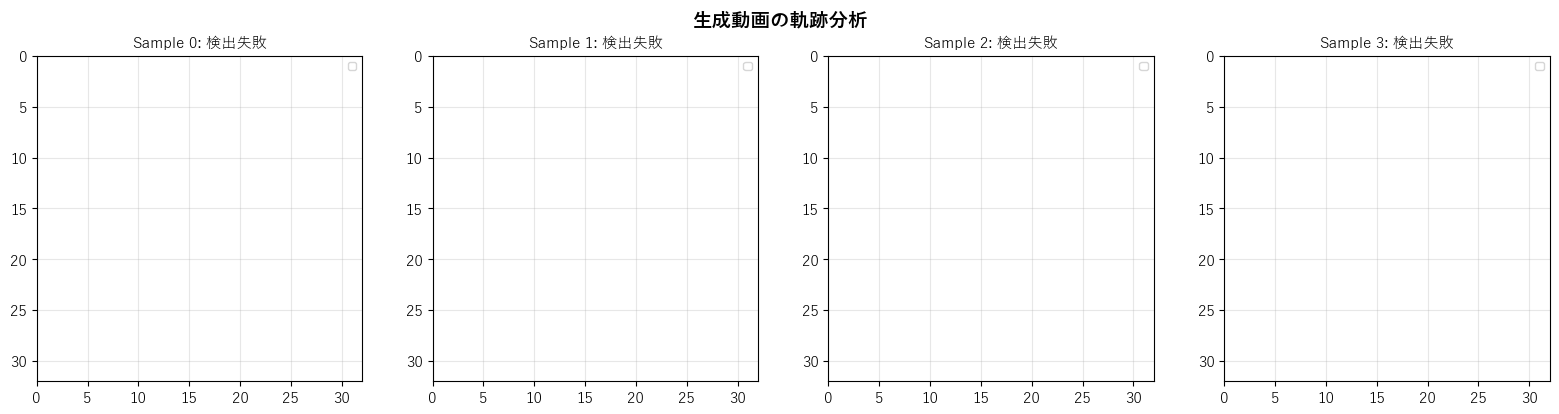


✅ 生成データの軌跡分析完了


In [21]:
# ============================================================
# 生成データの軌跡分析
# ============================================================

print("=" * 60)
print("生成データの軌跡分析")
print("=" * 60)

fig, axes = plt.subplots(1, n_gen, figsize=(4 * n_gen, 4))
if n_gen == 1:
    axes = [axes]

gen_results = []

for i in range(n_gen):
    video = generated_vis[i].cpu().permute(0, 2, 3, 1).numpy()  # (T, H, W, C)
    result = analyzer.analyze_video(video)
    gen_results.append(result)

    ax = axes[i]
    if result['valid']:
        pos = result['positions']
        colors = plt.cm.viridis(np.linspace(0, 1, len(pos)))
        for j in range(len(pos) - 1):
            ax.plot(pos[j:j+2, 0], pos[j:j+2, 1],
                    color=colors[j], linewidth=2)
        ax.scatter(pos[0, 0], pos[0, 1], c='green', s=60, zorder=5, label='開始')
        ax.scatter(pos[-1, 0], pos[-1, 1], c='red', s=60, zorder=5, label='終了')

        mt = result['motion_type']
        mt_jp = {'linear': '等速直線', 'parabolic': '放物線',
                 'bounce': '壁反射', 'unknown': '未分類'}
        ax.set_title(f'Sample {i}: {mt_jp.get(mt, mt)}\n'
                     f'R²={result["r2_linear"]:.2f}',
                     fontsize=11, fontweight='bold')
    else:
        ax.set_title(f'Sample {i}: 検出失敗', fontsize=11)

    ax.set_xlim(0, 32)
    ax.set_ylim(32, 0)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

    print(f"  Sample {i}: type={result.get('motion_type', 'N/A')}, "
          f"valid={result['valid']}, "
          f"R²_lin={result.get('r2_linear', 0):.3f}, "
          f"R²_para={result.get('r2_parabolic', 0):.3f}")

plt.suptitle('生成動画の軌跡分析', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("\n✅ 生成データの軌跡分析完了")

In [22]:
# ============================================================
# 物理的妥当性のサマリーレポート
# ============================================================

print("=" * 60)
print("物理的妥当性レポート")
print("=" * 60)

valid_results = [r for r in gen_results if r['valid']]
n_valid = len(valid_results)

print(f"\n有効なサンプル: {n_valid}/{n_gen}")

if n_valid > 0:
    r2_linear_vals = [r['r2_linear'] for r in valid_results]
    r2_para_vals = [r['r2_parabolic'] for r in valid_results]

    print(f"\n--- R²統計 ---")
    print(f"  線形R²:   平均={np.mean(r2_linear_vals):.3f}, "
          f"最小={np.min(r2_linear_vals):.3f}, 最大={np.max(r2_linear_vals):.3f}")
    print(f"  放物線R²: 平均={np.mean(r2_para_vals):.3f}, "
          f"最小={np.min(r2_para_vals):.3f}, 最大={np.max(r2_para_vals):.3f}")

    # 運動タイプ分布
    type_counts = {}
    for r in valid_results:
        mt = r['motion_type']
        type_counts[mt] = type_counts.get(mt, 0) + 1

    print(f"\n--- 運動タイプ分布 ---")
    type_jp = {'linear': '等速直線', 'parabolic': '放物線',
               'bounce': '壁反射', 'unknown': '未分類'}
    for mt, count in type_counts.items():
        print(f"  {type_jp.get(mt, mt)}: {count}サンプル")

    # 重力推定値
    gravity_estimates = [r['est_gravity'] for r in valid_results
                         if r['motion_type'] == 'parabolic']
    if gravity_estimates:
        print(f"\n--- 重力推定 ---")
        print(f"  設定値: {analyzer.sim_gravity}")
        print(f"  推定値: {np.mean(gravity_estimates):.3f} "
              f"(±{np.std(gravity_estimates):.3f})")

print(f"\n💡 注意: 10エポックの訓練では完全な物理的一貫性は期待できません。")
print(f"   訓練エポック数を増やし、データ数を増加させることで改善されます。")
print("\n✅ 物理的妥当性レポート完了")

物理的妥当性レポート

有効なサンプル: 0/4

💡 注意: 10エポックの訓練では完全な物理的一貫性は期待できません。
   訓練エポック数を増やし、データ数を増加させることで改善されます。

✅ 物理的妥当性レポート完了


<a id="summary"></a>
## 7. まとめ・よくあるエラー・自己評価クイズ

### 📊 この章で実装したもの

| コンポーネント | 概要 |
|-------------|------|
| `PhysicsSimulator2D` | NumPyベースの2D物理エンジン（3種類の運動） |
| `PhysicsVideoDataset` | PyTorch Dataset（on-the-fly生成） |
| `PhysicsDiT` | 時間的注意機構付き軽量DiT |
| `PhysicsVideoDiffusion` | DDPMベースの訓練・サンプリング |
| `TrajectoryAnalyzer` | 軌跡抽出・物理的妥当性の定量評価 |

### 🔗 Notebook 130-134との関連

```
[130] Temporal Attention → TemporalAttentionクラス
[131] Video Diffusion   → PhysicsVideoDiffusion (DDPM)
[132] DiT               → PhysicsDiT (adaLN-Zero)
[133] Camera vs Object  → PhysicsSimulator2D (物体運動)
[134] Temporal Consistency → TrajectoryAnalyzer (一貫性評価)
[112] Adam              → optimizer = Adam(lr=3e-4)
```

### ⚠️ よくあるエラー Top 3

---

#### エラー1: 生成動画が全フレーム同じに見える

```python
# ❌ 誤り: 時間的注意が機能していない
class BadDiT(nn.Module):
    def forward(self, x, t):
        B, T, C, H, W = x.shape
        # 全フレームを独立に処理し、時間的注意なし
        x_flat = x.reshape(B * T, C, H, W)
        tokens = self.patch_embed(x_flat)
        for block in self.spatial_blocks:
            tokens = block(tokens, t_emb)
        # TemporalAttentionが欠落!
        out = self.unpatchify(tokens)
        return out.reshape(B, T, C, H, W)
```

```python
# ✅ 修正: TemporalAttentionを追加
tokens_4d = tokens.reshape(B, T, N, dim)
tokens_4d = self.temporal_attn(tokens_4d)  # フレーム間の注意!
tokens = tokens_4d.reshape(B * T, N, dim)
```

**原因**: TemporalAttentionがないと、各フレームが独立に処理され、
フレーム間の一貫性が学習されません。

---

#### エラー2: 訓練損失が減少しない（NaNになる）

```python
# ❌ 誤り: 勾配爆発
optimizer.step()  # 勾配クリッピングなし
```

```python
# ✅ 修正: 勾配クリッピングを追加
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
optimizer.step()
```

**原因**: Transformerは勾配が大きくなりやすく、特にadaLN-Zeroの
パラメータが不安定になることがあります。

---

#### エラー3: サンプリングでボールが現れない

```python
# ❌ 誤り: 逆拡散の最後のステップでもノイズを追加
if t_idx >= 0:  # t=0でもノイズを追加してしまう
    noise = torch.randn_like(x_t)
    return mean + sigma * noise
```

```python
# ✅ 修正: t=0ではノイズなし
if t_idx > 0:  # t > 0 のときだけノイズを追加
    noise = torch.randn_like(x_t)
    return mean + sigma * noise
else:
    return mean  # 最終ステップはクリーンな出力
```

**原因**: DDPMの逆プロセスでは、最後のステップ（t=0）では
ノイズを追加しません。追加すると最終出力がぼやけます。

### 📝 自己評価クイズ

---

#### Q1: PhysicsDiTにおいて、空間注意と時間注意はどのように分離されていますか？

<details>
<summary>💡 答えを見る</summary>

**答え**: **分解型（Factorized）アーキテクチャ**を採用しています。

1. **空間注意**: 各フレームを独立にDiTBlockで処理
   - テンソル形状: `(B*T, N_patches, dim)` — フレームをバッチ次元に展開
   - 各フレーム内の64パッチ間でSelf-Attention

2. **時間注意**: 全フレームにわたるSelf-Attention
   - テンソル形状: `(B*N, T, dim)` — パッチ位置をバッチ次元に展開
   - 各パッチ位置について16フレーム間でSelf-Attention

この分解により、完全な時空間注意 `(T*N) × (T*N)` の計算量 $O(T^2 N^2)$ を
$O(TN^2 + NT^2)$ に削減しています。

</details>

---

#### Q2: adaLN-Zeroの「Zero」は何を意味しますか？

<details>
<summary>💡 答えを見る</summary>

**答え**: ゲーティングパラメータ $\alpha$ を**ゼロに初期化**することを意味します。

```python
nn.init.zeros_(self.adaLN_modulation[1].weight)
nn.init.zeros_(self.adaLN_modulation[1].bias)
```

$\alpha = 0$ のとき、ブロックの出力は恒等写像になります：
$$x_{out} = x + \alpha \cdot \text{Block}(x) = x + 0 = x$$

これにより、学習の初期段階で各ブロックが恒等写像として機能し、
深いTransformerでも安定した学習開始が可能になります。

Notebook 132の「DiTBlock内部の情報フロー」で詳しく解説しています。

</details>

---

#### Q3: コサインスケジュールが線形スケジュールより優れている理由は？

<details>
<summary>💡 答えを見る</summary>

**答え**: **ノイズレベルの変化がより滑らかで均一**だからです。

- **線形スケジュール**: $\beta_t$ が均一に増加するため、$\bar{\alpha}_t$ が急激に減少
  → 中間ステップでの学習信号が弱い
- **コサインスケジュール**: $\bar{\alpha}_t$ がコサイン曲線に従って緩やかに減少
  → 全ステップで均一な学習信号

特にステップ数が少ない場合（今回のT=200）、コサインスケジュールの方が
各ステップでの情報が均一に分布し、効率的な学習が可能です。

</details>

---

#### Q4: TrajectoryAnalyzerで「壁反射」を検出するための鍵となる指標は何ですか？

<details>
<summary>💡 答えを見る</summary>

**答え**: **速度の符号変化回数（sign changes）** です。

```python
sign_changes_x = np.sum(np.abs(np.diff(np.sign(velocities[:, 0]))) > 0)
```

- **等速直線運動**: 速度の符号変化 = 0（一定方向に移動）
- **放物線運動**: Y軸の速度は徐々に変化するが、急な符号変化は少ない
- **壁反射運動**: 壁に衝突するたびに速度が反転 → 符号変化 ≥ 2

この指標により、R²値だけでは区別しにくい壁反射運動を
効果的に検出できます。

</details>

---

#### Q5: 生成動画の物理的一貫性を向上させるために最も効果的な改善策は何ですか？

<details>
<summary>💡 答えを見る</summary>

**答え**: 以下の3つの改善策が特に効果的です：

1. **物理損失の追加（Physics-Informed Loss）**:
   通常のMSE損失に加えて、物理法則に基づく正則化を追加
   ```python
   # 例: 速度の滑らかさ制約
   velocity = x_pred[:, 1:] - x_pred[:, :-1]
   acceleration = velocity[:, 1:] - velocity[:, :-1]
   physics_loss = acceleration.pow(2).mean()  # 加速度の二乗を最小化
   ```

2. **訓練の充実**: エポック数の増加（10→100+）、データ数の増加（600→10000+）

3. **Classifier-Free Guidance**: 運動タイプラベルを条件として追加し、
   サンプリング時にガイダンスを適用して特定の物理パターンを強化

Notebook 134で学んだ「時間的一貫性技法」も参照してください。

</details>

---

### ✅ 学習チェックリスト

- [ ] PhysicsSimulator2Dで3種類の運動を生成・可視化できる
- [ ] PhysicsVideoDatasetのテンソル形状（T, C, H, W）を説明できる
- [ ] PhysicsDiTの空間注意と時間注意の分離を説明できる
- [ ] adaLN-Zero条件付けの役割とゼロ初期化の意味を理解している
- [ ] DDPMの前方拡散・逆拡散プロセスを実装できる
- [ ] コサインスケジュールの利点を説明できる
- [ ] TrajectoryAnalyzerで軌跡を抽出しR²を計算できる
- [ ] 生成動画の物理的妥当性を定量的に評価できる

---

### 📚 参考文献

- Ho et al., "Denoising Diffusion Probabilistic Models" (NeurIPS 2020)
- Peebles & Xie, "Scalable Diffusion Models with Transformers" (ICCV 2023)
- Ho et al., "Video Diffusion Models" (NeurIPS 2022)
- Nichol & Dhariwal, "Improved Denoising Diffusion Probabilistic Models" (ICML 2021)
- OpenAI, "Video generation models as world simulators" (Sora Technical Report, 2024)

---

**おめでとうございます！** 🎓

このCapstoneノートブックでは、Notebook 130-134で学んだ全ての技術を
統合して、物理法則に従う動画を生成するパイプラインを構築しました。

**次のステップ**: Notebook 136では、これらの技術をさらに発展させ、
より高解像度・長時間の時空間合成に取り組みます。